# [**E-Commerce - Kaggle**](https://www.kaggle.com/datasets/meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

df_raw = pd.read_csv('Data/customer_behave/customers.csv')
df_raw

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,C07996,United States,36,Male,Gold,2025-07-09,13,1953.76,175.38,40,Jewelry & Accessories,Tablet,Debit Card,Social Media,1,4.4,1,14,1,1
7996,C07997,India,42,Male,Free,2025-06-28,31,6772.20,251.76,53,Electronics,Mobile,Credit Card,Paid Ad,12,4.6,4,1,0,0
7997,C07998,India,34,Male,Platinum,2026-02-01,46,2430.09,58.01,18,Home & Kitchen,Desktop,Cryptocurrency,Organic Search,9,4.2,6,0,1,0
7998,C07999,Japan,44,Female,Free,2026-01-15,35,5552.56,147.22,50,Food & Grocery,Mobile,Credit Card,Paid Ad,10,4.1,1,2,0,0


In [2]:
df_raw.isnull().sum()

customer_id                 0
country                     0
age                         0
gender                      0
membership_tier             0
registration_date           0
total_orders                0
total_spend_usd             0
avg_order_value_usd         0
days_since_last_purchase    0
preferred_category          0
preferred_device            0
preferred_payment_method    0
acquisition_channel         0
reviews_given               0
avg_review_score            0
returns_made                0
wishlist_items              0
newsletter_subscribed       0
churned                     0
dtype: int64

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               8000 non-null   str    
 1   country                   8000 non-null   str    
 2   age                       8000 non-null   int64  
 3   gender                    8000 non-null   str    
 4   membership_tier           8000 non-null   str    
 5   registration_date         8000 non-null   str    
 6   total_orders              8000 non-null   int64  
 7   total_spend_usd           8000 non-null   float64
 8   avg_order_value_usd       8000 non-null   float64
 9   days_since_last_purchase  8000 non-null   int64  
 10  preferred_category        8000 non-null   str    
 11  preferred_device          8000 non-null   str    
 12  preferred_payment_method  8000 non-null   str    
 13  acquisition_channel       8000 non-null   str    
 14  reviews_given      

In [4]:
df = df_raw.drop(columns= ['customer_id']).copy()

df['registration_date'] = pd.to_datetime(df['registration_date'])

In [5]:
country_mapping = {
    'United States': 'North America', 'Mexico': 'North America', 'Canada': 'North America',
    'France': 'Europe', 'Germany': 'Europe', 'Netherlands': 'Europe', 
    'United Kingdom': 'Europe', 'Poland': 'Europe', 'Spain': 'Europe', 
    'Italy': 'Europe', 'Sweden': 'Europe',
    'South Africa': 'Africa',
    'UAE': 'Middle-East', 'Turkey': 'Middle-East',
    'Singapore': 'Asia', 'India': 'Asia', 'South Korea': 'Asia', 
    'Japan': 'Asia',
    'Australia': 'Australia',
    'Brazil': 'South America'
}

membership_mapping = {
    'Free'  :0, 
    'Silver':1, 
    'Gold'  :2, 
    'Platinum': 3,
}

df['region'] = df['country'].map(country_mapping)
df['membership'] = df['membership_tier'].map(membership_mapping)

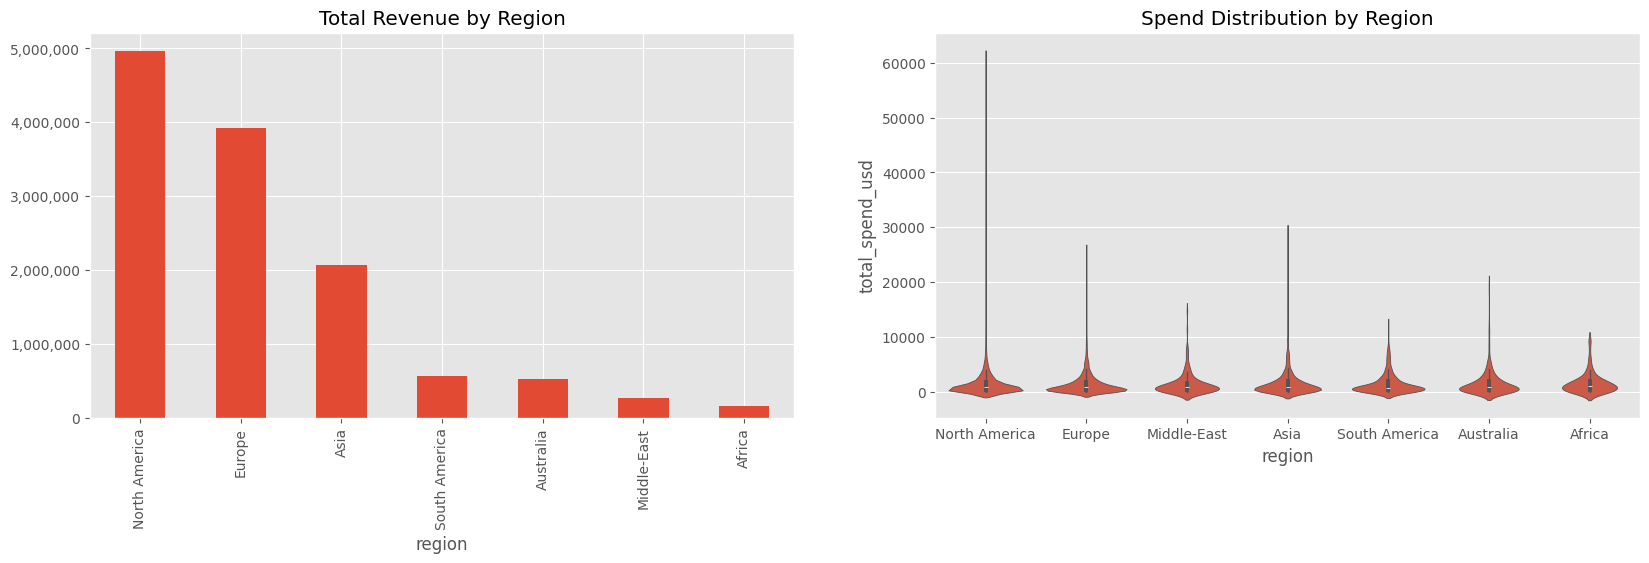

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

df.groupby('region')['total_spend_usd'].sum().sort_values(ascending=False).plot(kind='bar', ax=ax1)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax1.set_title('Total Revenue by Region')



sns.violinplot(df, x='region', y='total_spend_usd', ax=ax2)
ax2.set_title('Spend Distribution by Region')

plt.show()


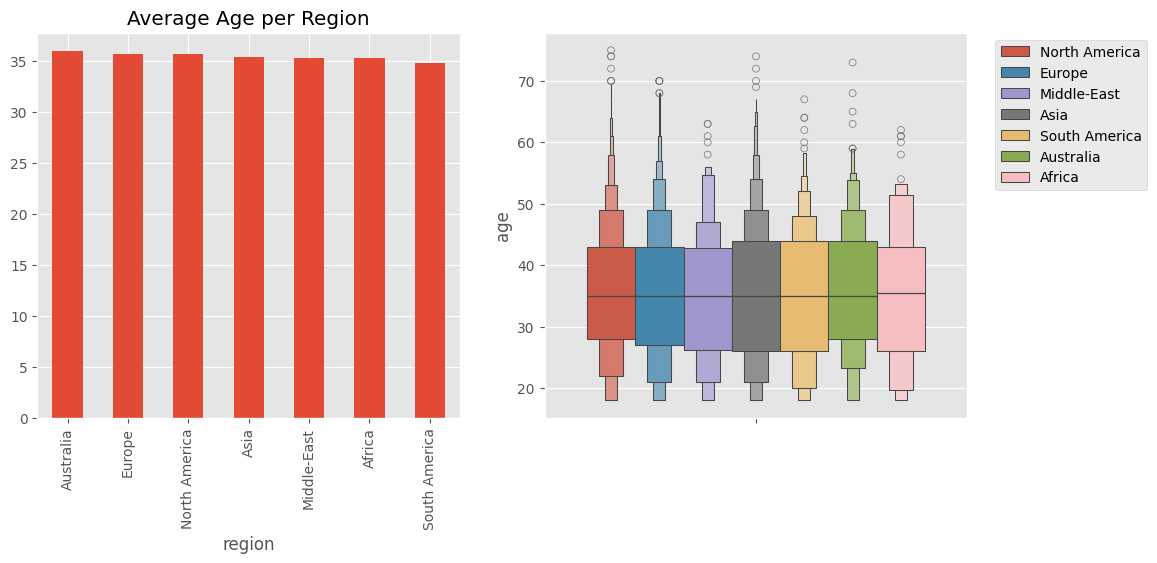

In [7]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
df.groupby('region')['age'].mean().sort_values(ascending= False).plot(kind = 'bar')
plt.title('Average Age per Region')

plt.subplot(1, 2, 2)
sns.boxenplot(df, y = 'age', hue = 'region')
plt.legend(bbox_to_anchor= (1.05, 1))
plt.show()

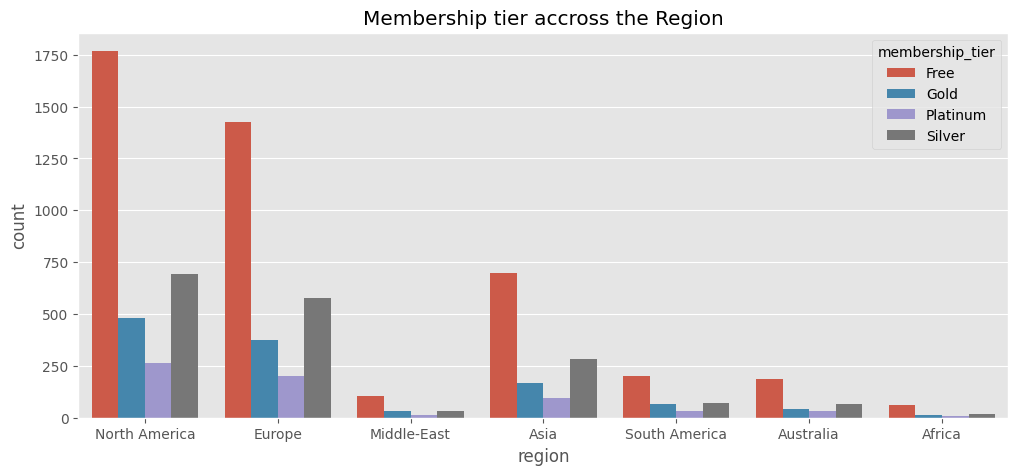

In [8]:
plt.figure(figsize = (12, 5))
sns.countplot(df, x = 'region', hue = 'membership_tier')
plt.title('Membership tier accross the Region')
plt.show()

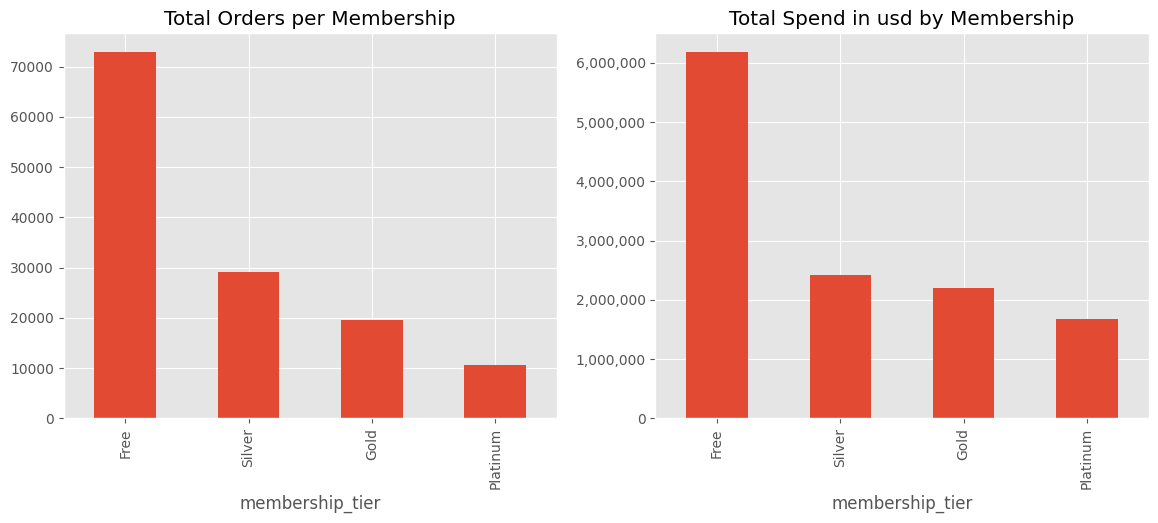

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('membership_tier')['total_orders'].sum().sort_values(ascending=False).plot(kind='bar', ax=ax1)
ax1.set_title('Total Orders per Membership')

df.groupby('membership_tier')['total_spend_usd'].sum().sort_values(ascending=False).plot(kind='bar', ax=ax2)
ax2.set_title('Total Spend in usd by Membership')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.show()




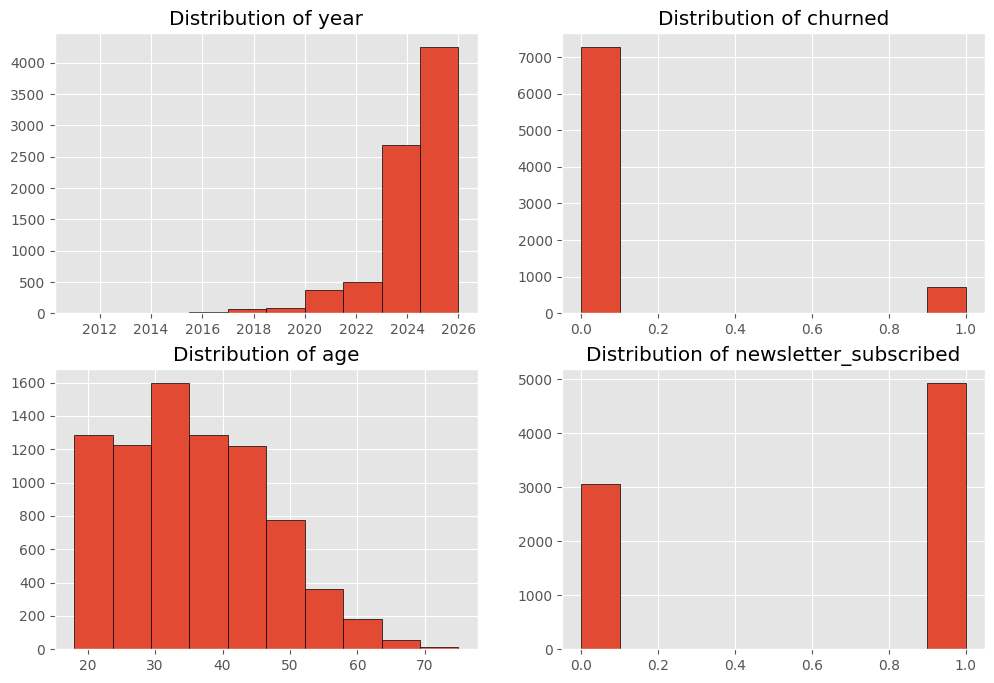

In [10]:
df['year'] = df['registration_date'].dt.year

feature = ['year', 'churned', 'age', 'newsletter_subscribed']
plt.figure(figsize = (12, 8))

for count, item in enumerate(feature):
    plt.subplot(2, 2, count + 1)
    df[item].hist(edgecolor = 'black')
    plt.title(f'Distribution of {item}')
plt.show()

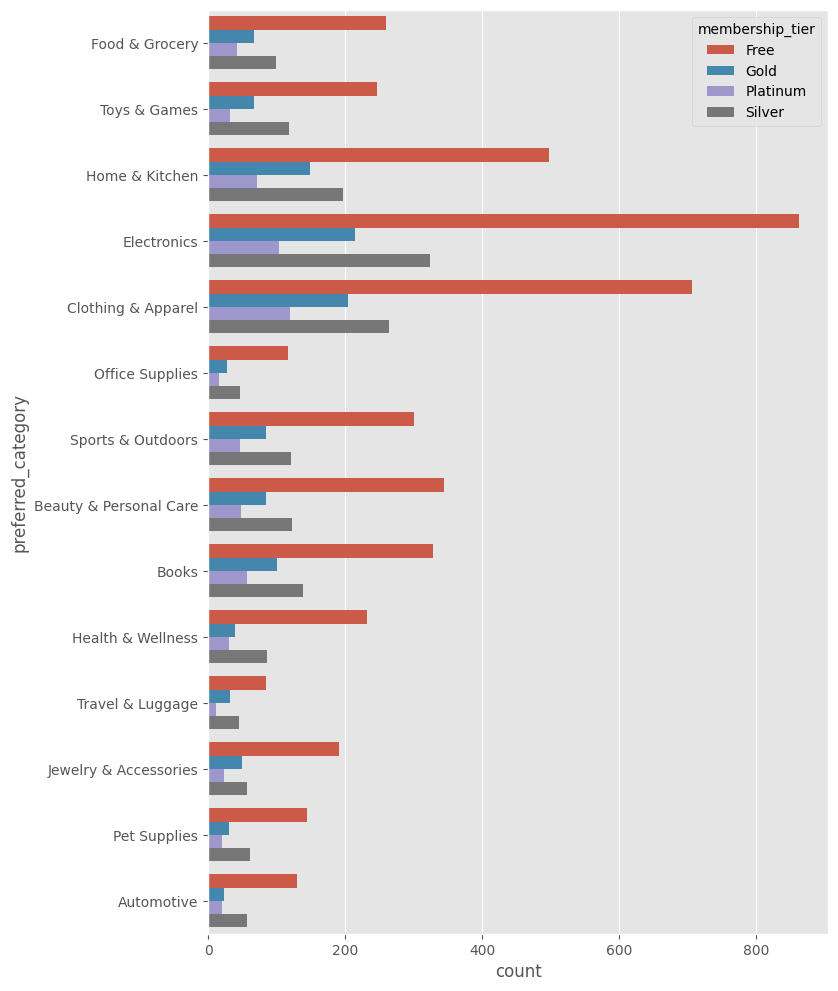

In [11]:
plt.figure(figsize = (8, 12))

sns.countplot(df, y = 'preferred_category', hue = 'membership_tier')
plt.show()

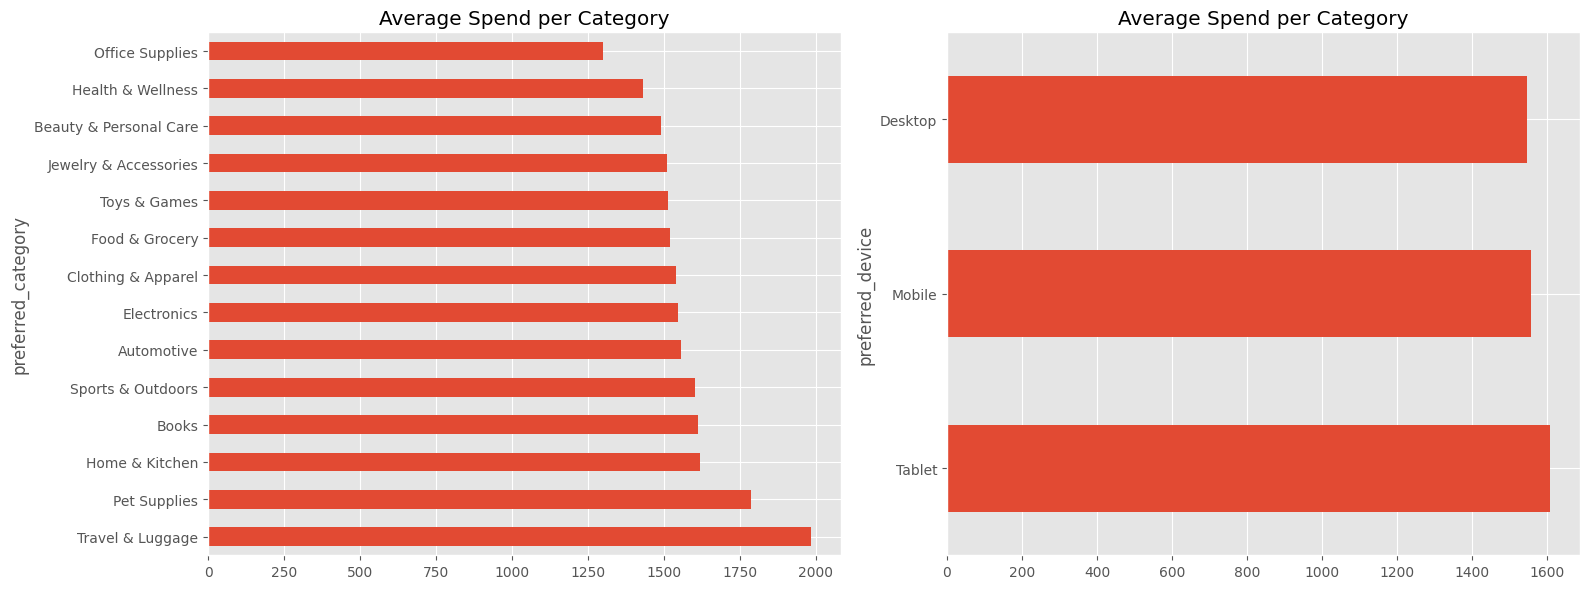

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Total spend per category
df.groupby('preferred_category')['total_spend_usd'].mean().sort_values(ascending=False).plot(kind='barh', ax=ax1)
ax1.set_title('Average Spend per Category')

df.groupby('preferred_device')['total_spend_usd'].mean().sort_values(ascending= False).plot(
    kind = 'barh', ax = ax2
)
ax2.set_title('Average Spend per Category')

plt.tight_layout()
plt.show()


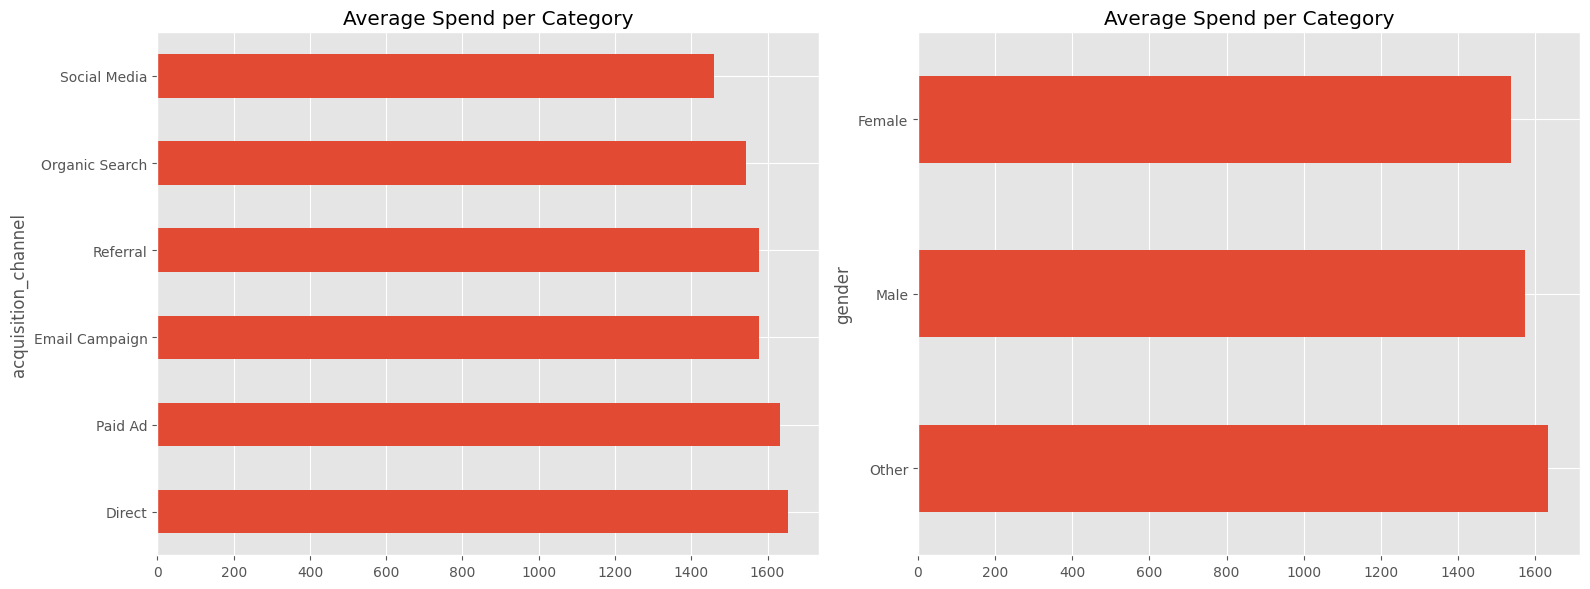

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Total spend per category
df.groupby('acquisition_channel')['total_spend_usd'].mean().sort_values(ascending=False).plot(kind='barh', ax=ax1)
ax1.set_title('Average Spend per Category')

df.groupby('gender')['total_spend_usd'].mean().sort_values(ascending= False).plot(
    kind = 'barh', ax = ax2
)
ax2.set_title('Average Spend per Category')

plt.tight_layout()
plt.show()


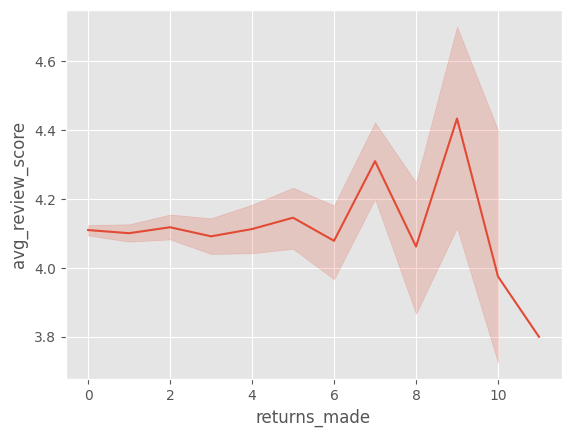

In [29]:
sns.lineplot(df, y = 'avg_review_score', x = 'returns_made')
plt.show()

### **EDA Analysis**:


In [13]:
string_col = df.select_dtypes(include=['str', 'object'])

for col in string_col:
    print(f'Feature: {col}')
    print(df[col].unique())
    print('-' * 50)

Feature: country
<ArrowStringArray>
[ 'United States',         'France',            'UAE',         'Canada',
      'Singapore', 'United Kingdom',    'Netherlands',         'Brazil',
         'Mexico',          'Japan',          'India',    'South Korea',
        'Germany',         'Poland',      'Australia',   'South Africa',
         'Turkey',          'Spain',          'Italy',         'Sweden']
Length: 20, dtype: str
--------------------------------------------------
Feature: gender
<ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
--------------------------------------------------
Feature: membership_tier
<ArrowStringArray>
['Free', 'Gold', 'Platinum', 'Silver']
Length: 4, dtype: str
--------------------------------------------------
Feature: preferred_category
<ArrowStringArray>
[        'Food & Grocery',           'Toys & Games',         'Home & Kitchen',
            'Electronics',     'Clothing & Apparel',        'Office Supplies',
      'Sports & Outdoors', '

In [14]:
df_encoded = pd.get_dummies(df, columns= ['region', 'gender', 'membership',
                                          'preferred_category', 'preferred_device',
                                          'preferred_payment_method', 'acquisition_channel',
                                          ], dtype = int)

df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 59 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   country                                        8000 non-null   str           
 1   age                                            8000 non-null   int64         
 2   membership_tier                                8000 non-null   str           
 3   registration_date                              8000 non-null   datetime64[us]
 4   total_orders                                   8000 non-null   int64         
 5   total_spend_usd                                8000 non-null   float64       
 6   avg_order_value_usd                            8000 non-null   float64       
 7   days_since_last_purchase                       8000 non-null   int64         
 8   reviews_given                                  8000 non-null   int64 